[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeyerBender/segtraq_workshop/blob/main/notebooks/task.ipynb)

# QC for Cell Segmentation with SpatialData and SegTraQ

Assessing the quality of cell segmentation in spatial transcriptomics (ST) data is much trickier than in images. In ST data, we do not only care about accurately capturing cellular morphology, but we also want to avoid contamination from transcripts that diffuse outside of their cell of origin. `SegTraQ` (**Seg**mentation and **Tra**nscript Assignment **Q**uality Assessment) provides metrics to assess exactly this, and can be used to identify spurious samples, cells, or to compare segmentation methods. In this workshop, we will have a look at some CosMx samples taken from [Lermi et al.](https://www.nature.com/articles/s41467-025-63414-1). We will use `spatialdata` to read in the data, `spatialdata-plot` to visualize it, and `SegTraQ` to assess how well segmentation worked for those samples.

In [1]:
# download the data
# if you have already run this cell once, there is no need to run it again

# use this when running on colab
! wget --no-check-certificate -O /content/data.tar.gz https://oc.embl.de/index.php/s/bBj36ET5S3v5VMW/download
! tar -xzf /content/data.tar.gz
! pip install --quiet segtraq==0.0.7 spatialdata==0.8.0 spatialdata_plot==0.4.2 anndata==0.12.8 seaborn==0.13.2 pandas==2.2.3
data_dir = '/content/data'

# use this when running locally (or on a cluster)
#! wget --no-check-certificate -O data.tar.gz https://oc.embl.de/index.php/s/bBj36ET5S3v5VMW/download
#! tar -xzf data.tar.gz
#data_dir = 'data'

--2026-10-07 15:24:45--  https://oc.embl.de/index.php/s/bBj36ET5S3v5VMW/download
Resolving oc.embl.de (oc.embl.de)... 10.11.5.116
Connecting to oc.embl.de (oc.embl.de)|10.11.5.116|:443... connected.
  Self-signed certificate encountered.
HTTP request sent, awaiting response... 200 OK
Length: 671094346 (640M) [application/gzip]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>] 640.00M   162MB/s    in 4.1s    

2026-10-07 15:24:50 (157 MB/s) - ‘data.tar.gz’ saved [671094346/671094346]



In [2]:
# importing required packages
import spatialdata as sd
import spatialdata_plot
import segtraq
import pandas as pd
import seaborn as sns
import warnings
import anndata as ad
import matplotlib.pyplot as plt
import os

# setting segtraq to use the maximum amount of cores for parallelization
segtraq.settings.n_jobs = -1

# colors that can be used for plotting later
CELLTYPE_COLORS = {
    "B":               "#929292",  # grey
    "Endothelial":     "#D98C6A",  # terracotta
    "Epithelial":      "#7DAA72",  # green
    "Fibroblast":      "#9A82B8",  # purple
    "ILC":             "#D5A85A",  # ochre
    "Lymphoid.Prolif": "#72AAA6",  # teal
    "Mac.Infiltrated": "#C98DA5",  # rose
    "Mac.PPARG":       "#9DA46F",  # olive
    "Mast":            "#B29A84",  # taupe
    "Mon":             "#829EB5",  # blue-grey
    "Myeloid.Prolif":  "#C87E82",  # muted red
    "NK-like":         "#8FB28A",  # sage
    "Neutrophil":      "#AD98C3",  # lavender
    "Pericyte":        "#D2B875",  # sand
    "Plasma":          "#6F91B5",  # blue
    "T.CD4":           "#B56F76",  # dusty red
    "T.CD8":           "#688F9E",  # slate teal
    "Tgd":             "#A68A64",  # warm brown
    "Treg":            "#7E82A8",  # muted indigo
    "cDC":             "#C49A6C",  # tan
    "pDC":             "#6F9B8C",  # muted sea green
    "Unassigned":      "#D3D3D3",  # light grey
}

# 1. Getting started

Before we can do anything with the data, we need to get it into `spatialdata` format. `Spatialdata-io` provides readers that do this for various technologies. For convenience, the data provided with this workshop is already in `spatialdata` format, so we can simply read it using `sd.read_zarr()`.

In [3]:
sd_dict = dict()
fovs = [5, 18, 24, 29, 45]
for fov in fovs:
    sd_dict[fov] = sd.read_zarr(os.path.join(data_dir, f'cosmx_fovs/GSM9046088_Lung_Adenocarcinoma_TMA1_CosMx_{fov}.zarr'))

Let's have a look at what these objects look like. We use FOV 45 as an example `sdata` object.

In [4]:
sdata = sd_dict[45]
sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/segtraq_workshop/notebooks/data/cosmx_fovs/GSM9046088_Lung_Adenocarcinoma_TMA1_CosMx_45.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (635193, 10) (2D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (1084, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (1084, 1010)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes)

We can use the name of each layer to access it. For example, let's look at the table.

In [5]:
sdata["table"]

AnnData object with n_obs × n_vars = 1084 × 1010
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'global'

We can also go further and look at the `obs` directly.

In [6]:
sdata["table"].obs.head()

,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,Mean.B2M.MembraneStain,Max.B2M.MembraneStain,Mean.CD45,Max.CD45,Mean.DAPI,Max.DAPI,fov_labels,cell_ID,region
1_45,45,7858,0.82,94,115,11,737,13,4914,184,3159,20,4830,171,806,45_shapes,1,cell_boundaries
2_45,45,6408,1.34,98,73,22,816,4,280,98,1180,7,180,319,1039,45_shapes,2,cell_boundaries
3_45,45,5111,1.13,86,76,26,152,6,341,387,1868,8,512,298,1441,45_shapes,3,cell_boundaries
4_45,45,5312,1.42,98,69,32,272,2,270,272,1563,4,275,345,1007,45_shapes,4,cell_boundaries
5_45,45,4234,1.01,80,79,7,643,17,5810,166,3286,19,5048,201,734,45_shapes,5,cell_boundaries


Let's also quickly have a look at the transcripts and cell boundaries. Explore the `spatialdata` object a bit. How are transcripts and cell boundaries stored?

In [7]:
# TODO:
# access the transcripts and the cell_boundaries layers

,x,y,target,cell_ID,y_global_px,CellComp,z_raw,Unnamed: 0,x_global_px,fov
0,3569.99,4231.7000,IGHA1,0,-60109.966667,<NA>,0,23293501,-461213.343333,45
1,3547.50,4228.1800,PARP1,0,-60113.486667,<NA>,0,23293502,-461235.833333,45
2,3426.96,4221.8429,IGHG1,0,-60119.823767,<NA>,0,23293503,-461356.373333,45
3,3471.30,4213.7500,IGHG1,0,-60127.916667,Membrane,0,23293504,-461312.033333,45
4,3529.04,4211.0400,B2M,0,-60130.626667,<NA>,0,23293505,-461254.293333,45


# 2. Plotting the data

Now that we have a feel for the data, we can try to plot some things. To do this, we use `spatialdata-plot`. Let's start by plotting some cells and transcripts.

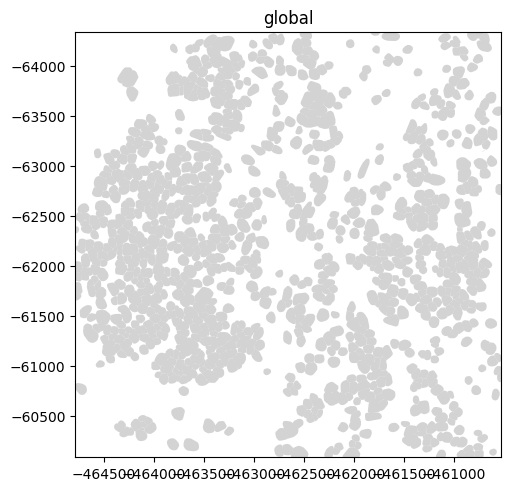

In [9]:
sdata.pl.render_shapes().pl.show()

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


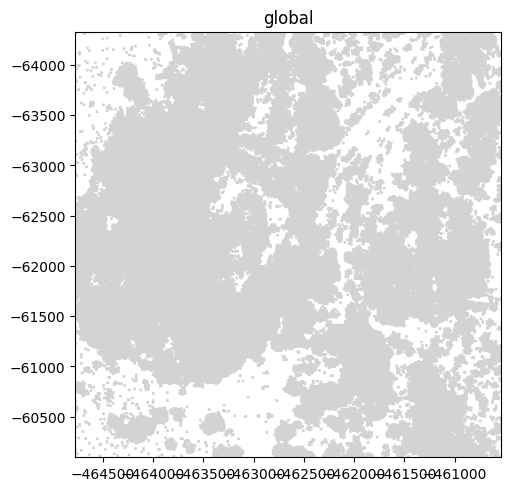

In [10]:
sdata.pl.render_points().pl.show()

We can also plot them on top of one another. For simplicity, we now only look at a couple of genes.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


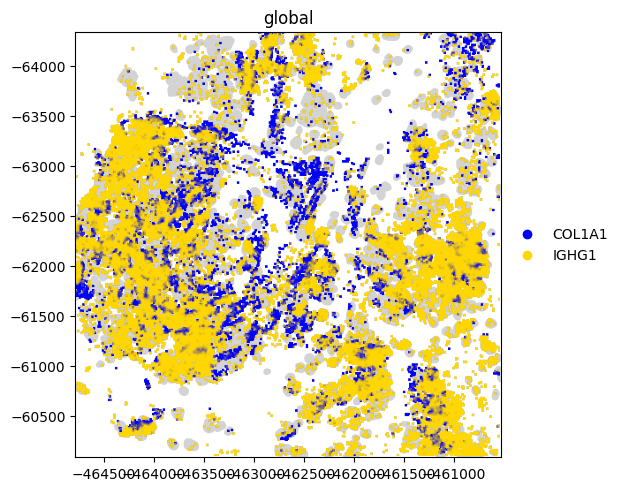

In [11]:
(sdata.pl.render_shapes()
      .pl.render_points(color='target', groups=["COL1A1", "IGHG1"], palette=["blue", "gold"])
      .pl.show())

# 3. Loading the data into SegTraQ

One common issue with spatial transcriptomics data is that each vendor calls things differently. For example, some technologies have a `gene` column, others call it `target`. One technology might have `x`, the other one `x-centroid`, and so on. Even within a single `spatialdata` object, there can be inconsistencies. For example, cells are identified via `cell_ID` in the transcripts data frame, but called `cellID` in the cell boundaries.


We do not want to define this every time we compute a metric. To deal with this, `SegTraQ` uses a constructor where you define these parameters once. Try using `segtraq.SegTraQ(sdata)` to load the data. **This will initially raise an error,** because you need to define additional keywords. Give it a try, and see which parameters you need to specify to get it working.

In [12]:
# TODO: 
# the code below will raise an error
# this is expected, because we first need to set the appropriate arguments
# see if you can figure out how to set them
st = segtraq.SegTraQ(sdata)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1862: UserWarning: Setting column 'cellID' as the index for shapes 'cell_boundaries', as this is required to link the table to shapes in SpatialData.
  shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:160: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:188: UserWarning: Filtering control probes matching prefixes ('NegControlProbe_', 'antisense_', 'NegControlCodeword', 'BLANK_', 'Blank-', 'NegPrb', 'DeprecatedCodeword_', 'UnassignedCodeword_', 'Intergenic_Region_') and transcripts with qv < 20 from transcript points in-place; control probes are also removed from the expression table if present. Configure `min_qv`, `control_prefixes`, and `inplace` via `filter_kwargs`.
  

As you can see, there are some warnings. These tell you that negative control probes were filtered out, and that there are some cells with 0 counts. We can ignore those for now. Let's now convert all of our `spatialdata` objects into `SegTraQ`.

In [13]:
st_dict = dict()

for fov, sdata_tmp in sd_dict.items():
    # TODO: apply the constructor from above to store all sdata objects as SegTraQ objects
    # write them into the st_dict

# 4. Computing some metrics
Now that we finally have the data in one consistent container, we can start to compute some metrics! Let's start with some baseline metrics, such as the number of segmented cells or the percentage of unassigned transcripts. We can compute these using `run_baseline()`.

In [14]:
for st in st_dict.values():
    st.run_baseline()

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:1537: UserWarning: The number of genes differs between points (916) and tables (1000). Example genes that are missed: ['RELA', 'CD164', 'PHLDA2', 'PDCD1', 'CD5L']. If these are control probes, please make sure to include them in the SegTraQ constructor. For example: SegTraQ(filter_kwargs={'control_prefixes': [...], 'control_genes': [...]}). Storing the number of genes from the points layer.
  return bl.num_genes(


Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

All results are written into the `spatialdata` object in-place, and can be found in `sdata["table"]`. Let's have a look!

In [15]:
# TODO:
# have a look what sdata["table"] looks like
# explore what information is stored in the obs, uns, and other layers

,centroid_x,centroid_y,gene_count,mean_transcripts_per_gene,transcript_count,transcript_density,num_polygons,cell_area,perimeter,circularity,solidity,convexity,elongation,eccentricity,compactness
1_45,2538.594066,4205.749645,86,1.976744,170,0.021634,1,8094.5,351.053711,0.825378,1.0,1.0,1.371623,0.684446,15.224993
2_45,4035.505930,4221.816305,84,4.369048,367,0.057272,1,6337.5,304.253417,0.860314,1.0,1.0,1.333333,0.661438,14.606728
3_45,3856.608422,4223.668478,70,4.085714,286,0.055958,1,5062.0,266.983784,0.892405,1.0,1.0,1.120000,0.450340,14.081458
4_45,3942.368742,4226.203304,84,4.357143,366,0.068901,1,5629.5,303.685061,0.767066,1.0,1.0,1.399328,0.699504,16.382381
5_45,2605.393799,4196.714423,47,1.510638,71,0.016769,1,4327.5,245.721283,0.900661,1.0,1.0,1.120444,0.451041,13.952386


Let's put some of this information into a data frame and plot the results.

In [17]:
df = []

for fov, st in st_dict.items():
    uns = st.sdata["table"].uns
    df.append([fov, uns['num_cells'], uns['perc_unassigned_transcripts'], uns['num_transcripts']])
    
df = pd.DataFrame(df, columns=['fov', 'num_cells', 'perc_unassigned_transcripts', 'num_transcripts'])

<Axes: xlabel='num_cells', ylabel='perc_unassigned_transcripts'>

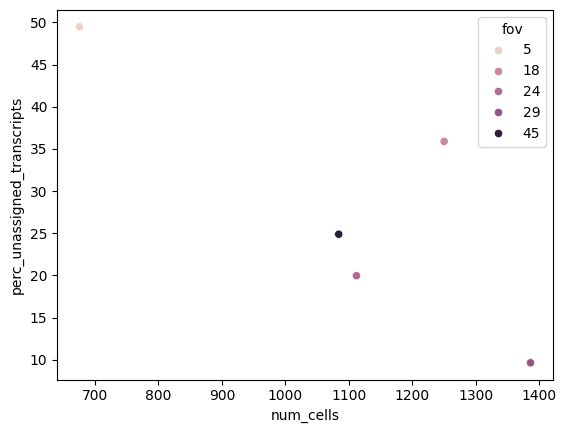

In [18]:
# TODO:
# look at the percentage of unassigned transcripts per cell
# do you spot anything unusual?
# Hint: you could do this by plotting a scatterplot, showing the number of cells vs. the percentage of unassigned transcripts

In [ ]:
# plot the transcripts and cell boundaries from the outlying sample
# what do you observe?

We can also check the number of transcripts for each sample.

In [20]:
df[['fov', 'num_transcripts']]

,fov,num_transcripts
0,5,586501
1,18,4498
2,24,177480
3,29,1000918
4,45,634705


We can see that sample 18 has a surprisingly low number of transcripts. Let's check what's going on here.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


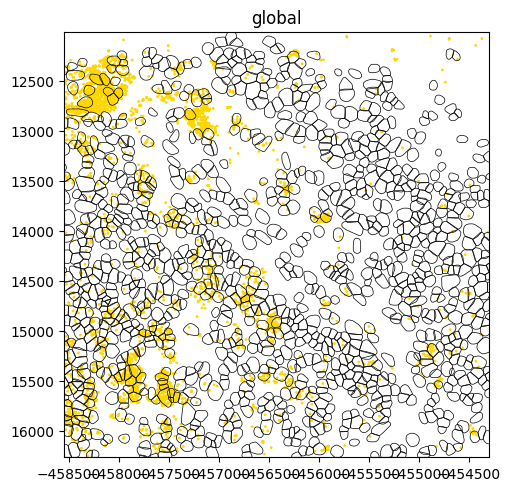

In [21]:
# TODO:
# plot the transcripts and cell boundaries for sample 18
# what do you see?

Looks like transcript detection did not work in this sample! In an actual analysis setting, you would remove such a sample before performing downstream analysis.

# 5. Using scRNA-seq information
With the baseline metrics, we were already able to detect various issues with the segmentation and with the data. For the last part of this workshop, we are going to look at some more elaborate metrics that can tell us if a sample shows signs of transcript spillage between cells.

More specifically, we will now use an annotated scRNA-seq dataset to transfer cell type labels onto our spatial transcriptomics data. We then use this RNAseq data to figure out which genes should be expressed in which cell type, and check for contamination this way. The scRNA-seq data is from a publicly available dataset on [CELLxGENE](https://datasets.cellxgene.cziscience.com/a95f7e58-a8fb-4fcd-b55f-e074cdae155b.h5ad).

Note that the `supervised` module is the only module in `SegTraQ` that requires scRNA-seq data. The other five modules are only dependent on the spatial transcriptomics data.

In [22]:
# reading the data (already in anndata format)
adata_ref = ad.read_h5ad(os.path.join(data_dir, 'lung_adenocarcinoma_scrnaseq.h5ad'))
adata_ref

AnnData object with n_obs × n_vars = 117266 × 57398
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

We can simply use the `run_supervised()` function to run both label transfer and the supervised metrics all in one go. Here, we only show this for one sample, but you could also compute this for all of them.

In [23]:
st_dict[45].run_supervised(adata_ref=adata_ref, ref_cell_type='author_cell_type_level_1', ref_gene_key='gene_symbol')

Supervised:   0%|          | 0/5 [00:00<?, ?step/s]

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:443: UserWarning: Gene identifiers are not unique. Making them unique with `adata_ref.var_names_make_unique()`.
  adata_ref = _make_ref_genes_unique(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:443: UserWarning: Gene identifiers are not unique. Making them unique with `adata_ref.var_names_make_unique()`.
  adata_ref = _make_ref_genes_unique(


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:1872: RuntimeWarning: neighbors_key='spatial_connectivities' not found in adata.obsp. A neighborhood graph based on Delaunay will be computed.
  return sp.marker_purity(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:443: UserWarning: Gene identifiers are not unique. Making them unique with `adata_ref.var_names_make_unique()`.
  adata_ref = _make_ref_genes_unique(


Before investigating the results of the metrics, we first visualize the cell types.

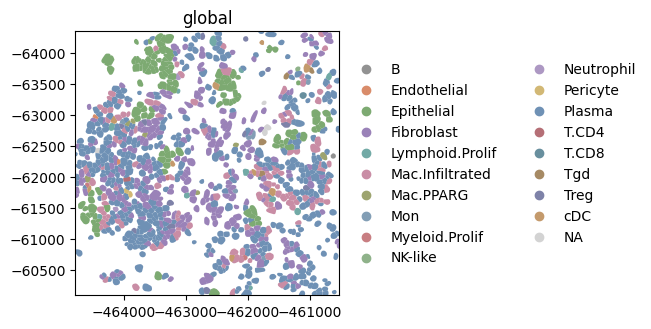

In [24]:
sdata.pl.render_shapes(color='transferred_cell_type', palette=CELLTYPE_COLORS).pl.show()

Let's focus on sample 45 again and have a look at some of the metrics, starting with the contamination strength matrix.

/tmp/ipykernel_9249/1211363218.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  cont_strength_mat.stack(dropna=False)
/tmp/ipykernel_9249/1211363218.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  plot_df["n_evaluable"] = cont_n.stack(dropna=False).values


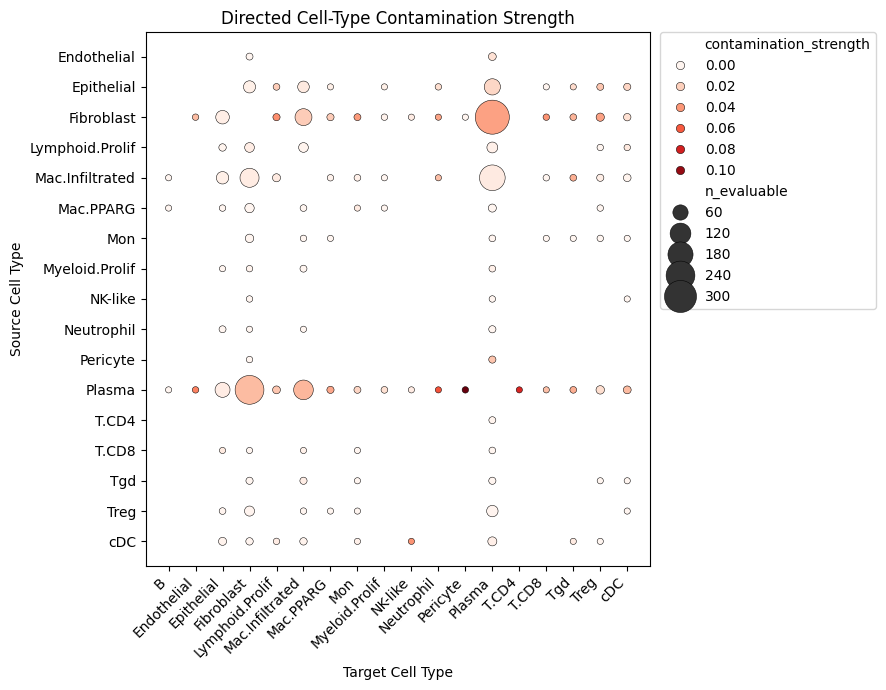

In [25]:
cont_strength_mat = sdata["table"].uns["contamination_strength_matrix"]
cont_n = sdata["table"].uns["contamination_evaluable_cells_matrix"]

plot_df = (
    cont_strength_mat.stack(dropna=False)
    .rename("contamination_strength")
    .reset_index()
    .rename(columns={"level_0": "source", "level_1": "target"})
)

plot_df["n_evaluable"] = cont_n.stack(dropna=False).values

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=plot_df,
    x="target",
    y="source",
    size="n_evaluable",
    hue="contamination_strength",
    sizes=(20, 600),
    palette="Reds",
    edgecolor="black",
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Directed Cell-Type Contamination Strength")
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

We can see a lot of contamination between fibroblasts and plasma cells. We can look at the mutually exclusive coexpression rate (MECR) to get a sense for what is going on here. The MECR provides gene pairs that should not occur within the same cell (according to the scRNA-seq reference dataset), but do.

In [26]:
mecr_df = sdata["table"].uns['mutually_exclusive_coexpression_rate']
# filtering by adjusted p-value and odds ratio
mecr_df = mecr_df[(mecr_df['pvalue_adj'] < 0.05) & (mecr_df['odds_ratio'] > 1)]
# sorting by coexpression fraction
mecr_df = mecr_df.sort_values(by='coexpression_fraction', ascending=False)
mecr_df.head(10)

,gene1,gene2,odds_ratio,pvalue,pvalue_adj,a,b,c,d,coexpression_fraction
8519,IGFBP7,IGHG2,2.295385,1.741681e-05,0.013310,378,34,557,115,0.348708
1132,BGN,IGHG2,2.280754,5.579228e-05,0.025026,323,28,612,121,0.297970
6659,DCN,IGHM,1.799416,1.329913e-06,0.002033,252,237,221,374,0.232472
5206,COL6A1,IGHM,1.656983,2.908784e-05,0.018307,239,233,234,378,0.220480
4945,COL3A1,MZB1,2.048441,1.245729e-08,0.000133,230,279,165,410,0.212177
5061,COL5A1,IGHG2,2.489531,1.672746e-04,0.040043,227,17,708,132,0.209410
5215,COL6A1,MZB1,1.598090,1.448884e-04,0.040043,201,271,194,418,0.185424
5250,COL6A2,MZB1,1.560591,3.091532e-04,0.049051,192,260,203,429,0.177122
8523,IGFBP7,MZB1,1.763199,7.701360e-06,0.009155,184,228,211,461,0.169742
1133,BGN,IGHM,1.663978,6.315632e-05,0.025026,183,168,290,443,0.168819


We can once again visualize the results spatially.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.

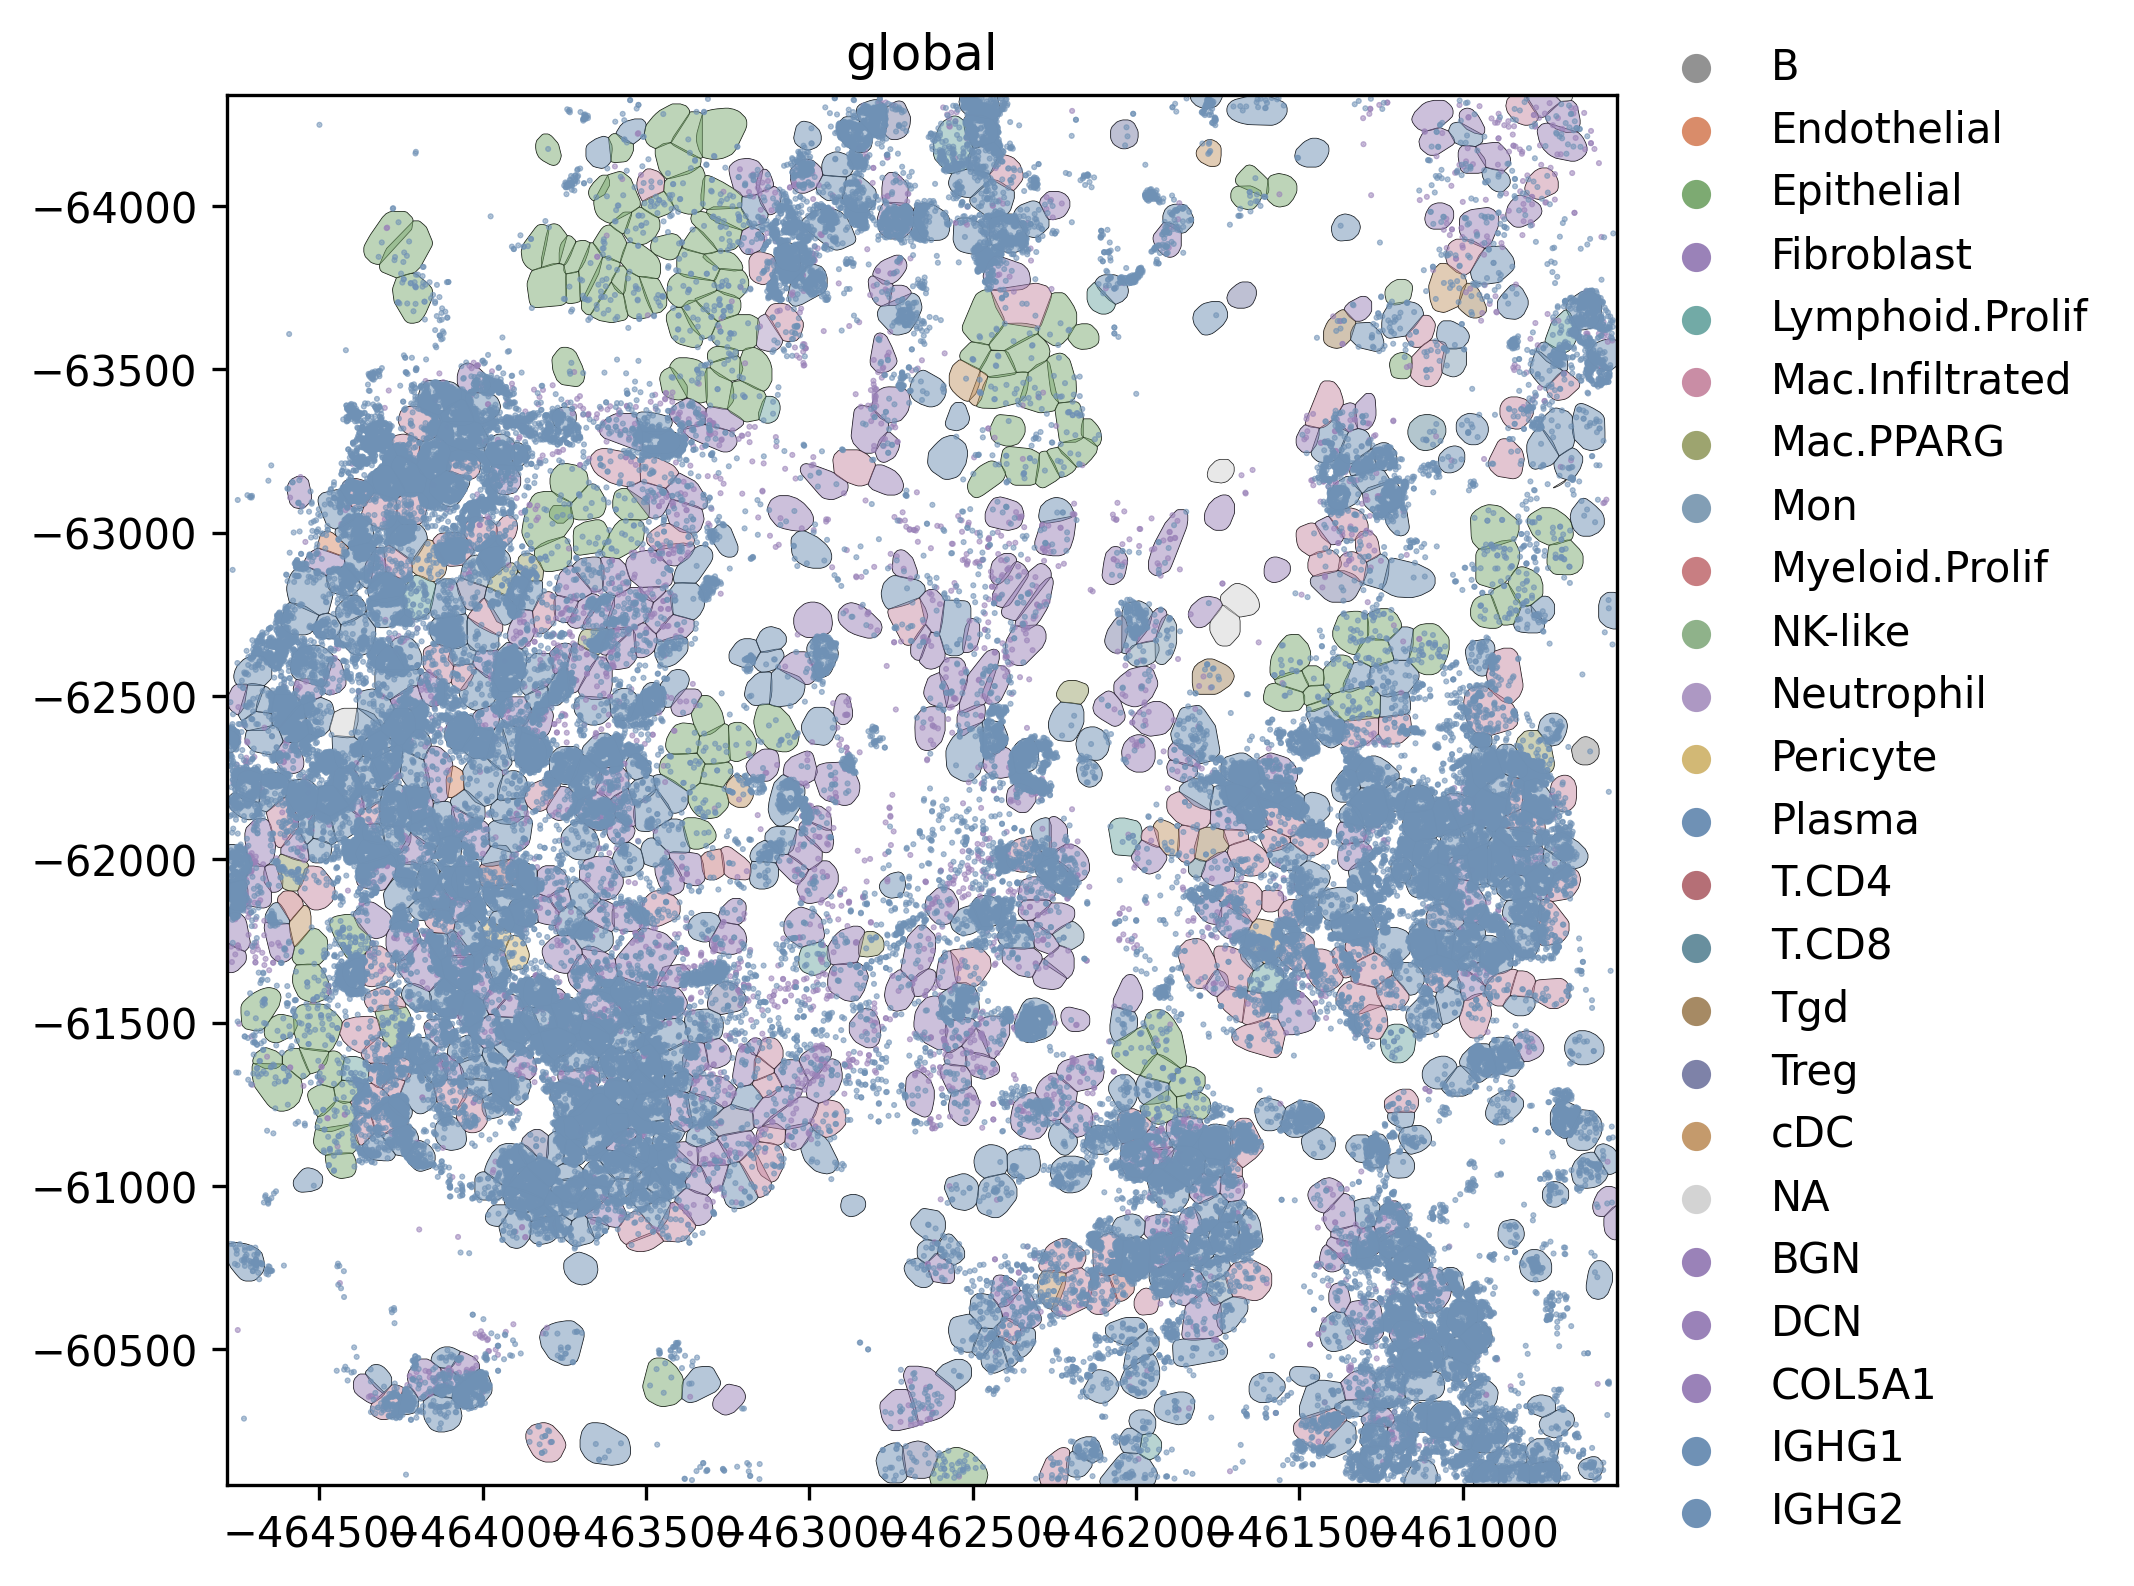

In [27]:
# TODO:
# pick some genes from the list above, and research in which cell types they should be expressed
# plot those genes and the cells (colored by cell type) using spatialdata-plot

Finally, let's check which cells are particularly affected.

WARNING  render_shapes: Found 105 NaN values in color data. These observations will be colored with the 'na_color'.


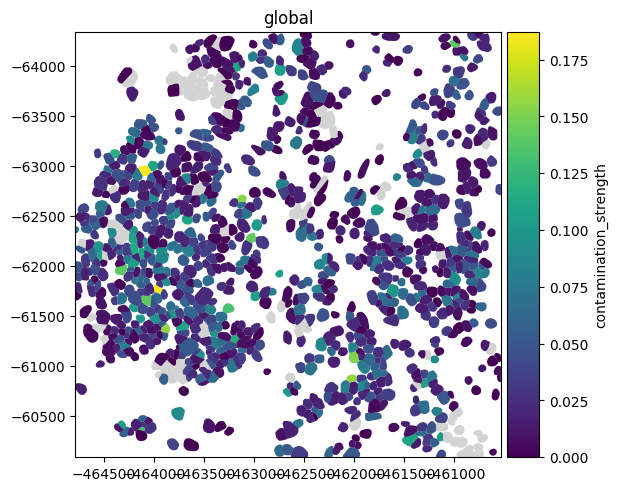

In [28]:
# TODO:
# render the cell boundaries, and color them by the contamination_strength

# 6. Play around

We have gone through two of `SegTraQ`'s modules here. But there are many more that look at other aspects of segmentation quality, from subcelluar distribution of transcripts to clustering stability. Have a look at the [documentation](https://lazdaria.github.io/SegTraQ/index.html), and feel free to play around with the data!